In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA




In [ ]:
patients = pd.read_csv("/content/patients.csv")
admissions = pd.read_csv("/content/admissions.csv")
diagnoses = pd.read_csv("/content/diagnoses_icd.csv")
lab_events = pd.read_csv("/content/lab_for_survival.csv")


In [ ]:
patients.head(3)

,subject_id,gender,anchor_age,anchor_year,anchor_year_group,dod
0,10000032,F,52,2180,2014 - 2016,2180-09-09
1,10000048,F,23,2126,2008 - 2010,NaN
2,10000068,F,19,2160,2008 - 2010,NaN


In [ ]:
# Preprocess Patients / Admissions (updated)
patients['dod'] = pd.to_datetime(patients['dod'], errors='coerce')
admissions['admittime'] = pd.to_datetime(admissions['admittime'], errors='coerce')
admissions['dischtime'] = pd.to_datetime(admissions['dischtime'], errors='coerce')

# Merge patients with admissions
adm = admissions.merge(patients[['subject_id','gender','anchor_age','dod']], on='subject_id', how='left')
adm['age'] = adm['anchor_age']

# Event and survival time
adm['event'] = adm['dod'].notnull().astype(int)
adm['time'] = ((adm['dod'].fillna(adm['dischtime'])) - adm['admittime']).dt.total_seconds() / 3600 # hours
adm['time_years'] = adm['time'] / 8766
# Fill missing age with median
adm['age'] = adm['age'].fillna(adm['age'].median())



In [ ]:
#Comorbidities
#Ensure ICD codes are uppercase and stripped
diagnoses['icd_code'] = diagnoses['icd_code'].str.upper().str.replace('.', '', regex=False)

comorb_def = {

 'htn': ['401.9','402.90','403.90','404.90','405.9','I10','I11','I12','I13','I14','I15','I16'],
 'ckd': ['585.9','586','N18','N19'],
 'heart_failure': ['428.9','I50'],
 'cad': ['413.9','410.9','410.9','411.89','413.9','414.9','I20','I21','I22','I23','I24','I25'],
 'copd': ['496','J44'],
 'liver_dz': ['571.0','573.3','572.8','571.49','571.5','573.8','573.9','K70','K71','K72','K73','K74','K75','K76','K77'],
 'cancer': ['140-209','C'],
 'diabetes': ['250.1','250.0','250.8','250.8','250.9','E10','E11','E12','E13','E14']
}

comorb_list = []
for name, prefixes in comorb_def.items():
    df_flag = (
        diagnoses[diagnoses['icd_code'].str.startswith(tuple(prefixes))]
        .groupby(['subject_id','hadm_id'])
        .size()
        .reset_index(name=name)
    )
    df_flag[name] = 1
    comorb_list.append(df_flag)

comorb = None
for df_flag in comorb_list:
    comorb = df_flag if comorb is None else comorb.merge(df_flag, on=['subject_id','hadm_id'], how='outer')
comorb = comorb.fillna(0)

adm = adm.merge(comorb, on=['subject_id','hadm_id'], how='left')
for c in comorb_def.keys():
    if c not in adm.columns:
        adm[c] = 0

In [ ]:
#Extract Labs
def extract_lab_first(itemids, new_name):
    temp = lab_events[lab_events['itemid'].isin(itemids)].copy()
    temp['charttime'] = pd.to_datetime(
    temp['charttime'],
    dayfirst=True,
    errors='coerce'
)
    first_lab = temp.sort_values(['subject_id','hadm_id','charttime']) \
                    .groupby(['subject_id','hadm_id']).first().reset_index()

    first_lab.rename(columns={'valuenum': new_name}, inplace=True)
    return first_lab[['subject_id','hadm_id', new_name]]


In [ ]:
labs_to_extract = {
    "creatinine": [50912, 51081],
    "bun": [51006, 51300],
    "hemoglobin": [50811],
    "glucose_24h_avg": [50809, 50931],
    "hba1c": [50852],
}


In [ ]:
for labname, ids in labs_to_extract.items():
    lab_df = extract_lab_first(ids, labname)
    adm = adm.merge(lab_df, on=['subject_id','hadm_id'], how='left')
    adm[labname] = adm[labname].fillna(adm[labname].median())


In [ ]:
#Urine_output
urine = lab_events[lab_events['itemid']==51070].copy()
urine['charttime'] = pd.to_datetime(urine['charttime'], dayfirst=True, errors='coerce')

urine = urine.merge(adm[['subject_id','hadm_id','admittime']], on=['subject_id','hadm_id'])
u24 = urine[(urine['charttime'] - urine['admittime']).dt.total_seconds() <= 24*3600]

u24_sum = u24.groupby(['subject_id','hadm_id'])['valuenum'].sum().reset_index()
u24_sum.rename(columns={'valuenum':'urine_24h'}, inplace=True)

adm = adm.merge(u24_sum, on=['subject_id','hadm_id'], how='left')
adm['urine_24h'] = adm['urine_24h'].fillna(adm['urine_24h'].median())


In [ ]:
cluster_features = [
    'age','gender','creatinine','bun','hba1c','urine_24h',
    'htn','ckd','heart_failure','cad','copd','liver_dz','cancer','diabetes'
]

df_model = adm[['subject_id','hadm_id'] + cluster_features + ['time_years','event']].copy()
# FIX NEGATIVE OR ZERO SURVIVAL TIMES
df_model = df_model[df_model['time_years'] >= 0].copy()

# optional: also drop unrealistic long survival times (>20 years)
df_model = df_model[df_model['time_years'] <= 20]

# Encode gender
df_model['gender'] = df_model['gender'].map({'M':0,'F':1})




In [ ]:
# Ensure numeric & fill missing
df_model[cluster_features] = df_model[cluster_features].apply(pd.to_numeric, errors='coerce')
df_model[cluster_features] = df_model[cluster_features].fillna(df_model[cluster_features].median())

# Drop rows with missing survival info
df_model = df_model.dropna(subset=['time_years','event'])
df_model['event'] = df_model['event'].astype(int)

In [ ]:
df_model.shape

(430485, 18)

In [ ]:
df_model.columns.to_list()

['subject_id',
 'hadm_id',
 'age',
 'gender',
 'creatinine',
 'bun',
 'hba1c',
 'urine_24h',
 'htn',
 'ckd',
 'heart_failure',
 'cad',
 'copd',
 'liver_dz',
 'cancer',
 'diabetes',
 'time_years',
 'event']

In [ ]:
# Remove zero-variance features
vt = VarianceThreshold()
X_clean = vt.fit_transform(df_model[cluster_features])
X_clean = pd.DataFrame(X_clean, columns=np.array(cluster_features)[vt.get_support()])

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean)

# KMeans clustering
k = 4
kmeans = KMeans(n_clusters=k, random_state=42)
df_model['cluster'] = kmeans.fit_predict(X_scaled)

# Cluster median profiles
profiles = df_model.groupby('cluster')[cluster_features].median()
print(profiles)


          age  gender  creatinine   bun  hba1c  urine_24h  htn  ckd  \
cluster                                                               
0        56.0     1.0        0.90  16.0    6.2      497.0  1.0  0.0   
1        64.0     0.0        0.90  16.0    6.2      497.0  1.0  0.0   
2        64.0     0.0        3.15  61.0    6.2      497.0  1.0  0.0   
3        69.0     0.0        0.90  16.0    6.2      497.0  0.0  0.0   

         heart_failure  cad  copd  liver_dz  cancer  diabetes  
cluster                                                        
0                  0.0  0.0   0.0       0.0     0.0       0.0  
1                  0.0  0.0   0.0       0.0     0.0       1.0  
2                  0.0  0.0   0.0       0.0     0.0       0.0  
3                  0.0  0.0   1.0       0.0     0.0       0.0  


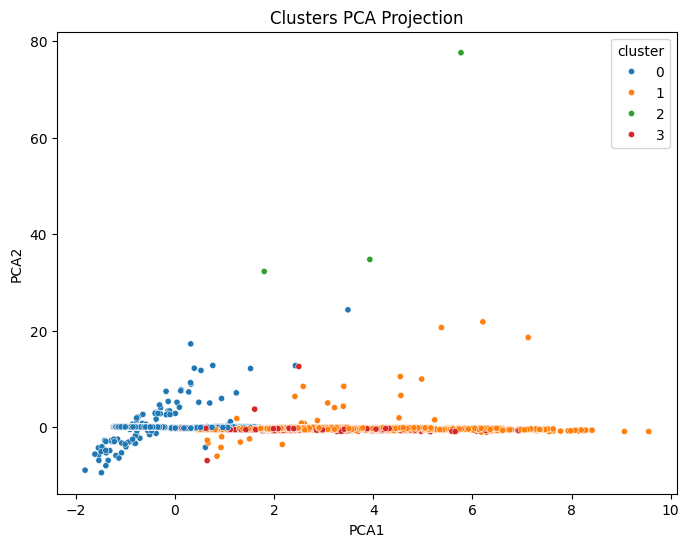

In [ ]:
pca = PCA(n_components=2)
embedding = pca.fit_transform(X_scaled)
df_model['PCA1'] = embedding[:,0]
df_model['PCA2'] = embedding[:,1]

plt.figure(figsize=(8,6))
sns.scatterplot(data=df_model.sample(20000), x='PCA1', y='PCA2', hue='cluster', palette='tab10', s=20)
plt.title("Clusters PCA Projection")
plt.show()


In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.utils import resample

# Candidate range of clusters
k_values = range(2, 10)

wcss = []
sil = []

# Use a sample for silhouette to speed up computation
sample = resample(X_scaled, n_samples=10000, random_state=42)

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42)

    # Fit on full dataset for WCSS (Elbow)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

    # Silhouette on sample only
    labels_sample = km.predict(sample)
    sil.append(silhouette_score(sample, labels_sample))

# Plot Elbow and Silhouette
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(k_values, wcss, '-o')
plt.title("Elbow Method (Full dataset)")
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")

plt.subplot(1,2,2)
plt.plot(k_values, sil, '-o')
plt.title("Silhouette Score (Sample)")
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette Score")

plt.show()


KeyboardInterrupt: 

In [ ]:
k = 4
kmeans = KMeans(n_clusters=k, random_state=42)
df_model['cluster'] = kmeans.fit_predict(X_scaled)


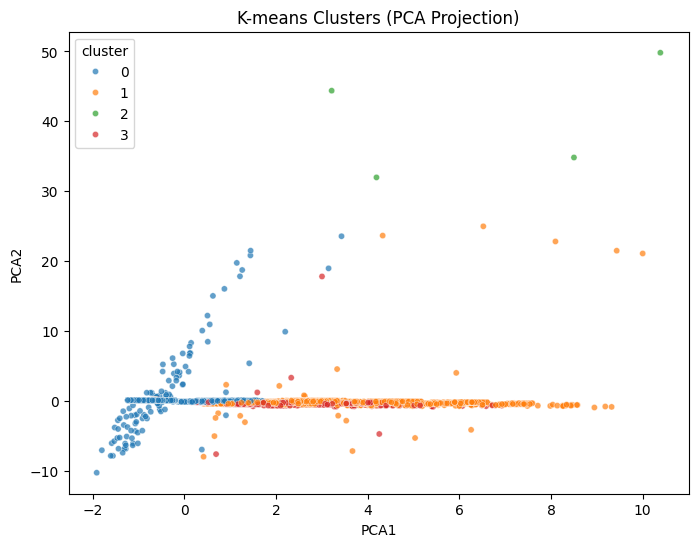

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Reduce to 2D with PCA
pca = PCA(n_components=2)
embedding = pca.fit_transform(X_scaled)

# Add PCA coordinates to dataframe
df_model['PCA1'] = embedding[:,0]
df_model['PCA2'] = embedding[:,1]

# Scatter plot of clusters
plt.figure(figsize=(8,6))
sns.scatterplot(data=df_model.sample(20000),  # subsample for speed
                x='PCA1', y='PCA2',
                hue='cluster', palette='tab10', s=20, alpha=0.7)
plt.title("K-means Clusters (PCA Projection)")
plt.show()



In [ ]:
!pip install lifelines

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 7.8 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=744c0827cc3e121750194c64d1fdd21cb3acce7250b2528358c4c773d20dd4a1
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


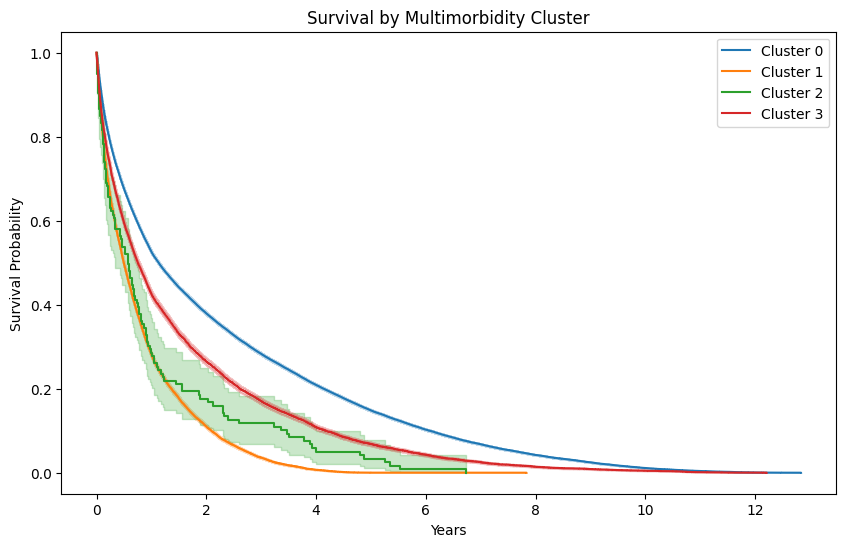

In [ ]:
from lifelines import KaplanMeierFitter, CoxPHFitter
km = KaplanMeierFitter()
plt.figure(figsize=(10,6))

for c, g in df_model.groupby('cluster'):
    km.fit(g['time_years'], g['event'], label=f"Cluster {c}")
    km.plot_survival_function()

plt.title("Survival by Multimorbidity Cluster")
plt.xlabel("Years")
plt.ylabel("Survival Probability")
plt.show()


In [ ]:
cox_vars = ['cluster'] + cluster_features + ['time_years','event']
df_cox = df_model[cox_vars].copy()
cph = CoxPHFitter()
cph.fit(df_cox, duration_col='time_years', event_col='event')
cph.print_summary()


<lifelines.CoxPHFitter: fitted with 430485 total observations, 324959 right-censored observations>
             duration col = 'time_years'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 430485
number of events observed = 105526
   partial log-likelihood = -1115338.18
         time fit was run = 2025-11-25 17:55:30 UTC

---
               coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                      
cluster        0.08      1.08      0.01            0.06            0.10                1.06                1.10
age            0.01      1.01      0.00            0.01            0.01                1.01                1.01
gender        -0.05      0.95      0.01           -0.06           -0.04                0.94                0.96
creatinine    -0.09      0.91      0.03           -0.16           -0.02                0.85                0.98
bun            0.01      1.01      0.00            0.01            0.02                1.01                1.02
hba1c         -0.15      0.86      0.09           -0.32            0.02                0.73                1.02
urine_24h     -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
htn           -0.12      0.89      0.02           -0.15           -0.09                0.86                0.91
ckd            0.17      1.19      0.01            0.14            0.20                1.15                1.22
heart_failure  0.23      1.26      0.01            0.20            0.26                1.22                1.29
cad            0.19      1.21      0.01            0.16            0.22                1.18                1.24
copd          -0.11      0.90      0.02           -0.16           -0.06                0.85                0.94
liver_dz       0.47      1.60      0.02            0.44            0.50                1.55                1.65
cancer         0.65      1.91      0.01            0.63            0.67                1.87                1.95
diabetes       0.06      1.06      0.01            0.03            0.08                1.03                1.09

               cmp to     z      p  -log2(p)
covariate                                   
cluster          0.00  7.51 <0.005     43.90
age              0.00 39.23 <0.005       inf
gender           0.00 -7.71 <0.005     46.16
creatinine       0.00 -2.67   0.01      7.02
bun              0.00  5.89 <0.005     27.97
hba1c            0.00 -1.78   0.07      3.74
urine_24h        0.00 -1.36   0.18      2.51
htn              0.00 -7.99 <0.005     49.41
ckd              0.00 12.15 <0.005    110.50
heart_failure    0.00 15.99 <0.005    188.75
cad              0.00 13.79 <0.005    141.26
copd             0.00 -4.68 <0.005     18.43
liver_dz         0.00 28.99 <0.005    611.35
cancer           0.00 57.21 <0.005       inf
diabetes         0.00  4.53 <0.005     17.35
---
Concordance = 0.61
Partial AIC = 2230706.36
log-likelihood ratio test = 11430.19 on 15 df
-log2(p) of ll-ratio test = inf

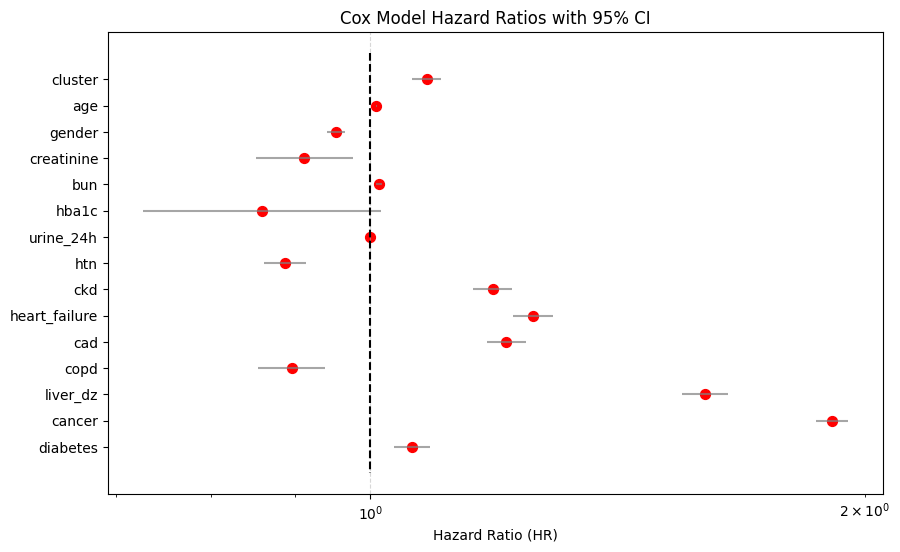

In [ ]:
import matplotlib.pyplot as plt

# Reset index; covariate names are now in 'covariate' column
summary = cph.summary.reset_index()

# Extract hazard ratios and 95% CI
hr = summary['exp(coef)']
hr_lower = summary['exp(coef) lower 95%']
hr_upper = summary['exp(coef) upper 95%']
variables = summary['covariate']  # use 'covariate', not 'variable'

# Plot
plt.figure(figsize=(10,6))
plt.hlines(variables, hr_lower, hr_upper, color='gray', alpha=0.7)  # CI lines
plt.scatter(hr, variables, color='red', s=50)  # HR points
plt.vlines(1, -1, len(variables), linestyles='dashed', color='black')  # reference line HR=1
plt.xscale('log')
plt.xlabel("Hazard Ratio (HR)")
plt.title("Cox Model Hazard Ratios with 95% CI")
plt.gca().invert_yaxis()
plt.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.show()


<lifelines.CoxPHFitter: fitted with 430485 total observations, 324959 right-censored observations>
             duration col = 'time_years'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 430485
number of events observed = 105526
   partial log-likelihood = -1115309.06
         time fit was run = 2025-12-01 22:12:55 UTC

---
               coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                      
age            0.01      1.01      0.00            0.01            0.01                1.01                1.01
gender        -0.05      0.95      0.01           -0.06           -0.04                0.94                0.96
creatinine    -0.08      0.92      0.04           -0.16           -0.01                0.86                0.99
bun            0.01      1.01      0.00            0.01            0.02                1.01                1.02
hba1c         -0.16      0.86      0.09           -0.32            0.01                0.72                1.01
urine_24h     -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
htn           -0.07      0.94      0.02           -0.10           -0.03                0.91                0.97
ckd            0.13      1.13      0.02            0.10            0.16                1.10                1.17
heart_failure  0.19      1.21      0.02            0.16            0.22                1.17                1.24
cad            0.15      1.16      0.01            0.12            0.18                1.13                1.19
copd          -0.03      0.97      0.03           -0.08            0.02                0.92                1.02
liver_dz       0.43      1.54      0.02            0.40            0.47                1.49                1.59
cancer         0.60      1.82      0.01            0.57            0.62                1.77                1.86
diabetes       0.01      1.01      0.01           -0.01            0.04                0.99                1.04
cluster_1      0.22      1.25      0.02            0.18            0.27                1.20                1.31
cluster_2      0.07      1.07      0.16           -0.25            0.39                0.78                1.48
cluster_3      0.21      1.23      0.03            0.15            0.27                1.16                1.31

               cmp to     z      p  -log2(p)
covariate                                   
age              0.00 39.42 <0.005       inf
gender           0.00 -7.74 <0.005     46.47
creatinine       0.00 -2.14   0.03      4.95
bun              0.00  5.69 <0.005     26.22
hba1c            0.00 -1.83   0.07      3.89
urine_24h        0.00 -1.25   0.21      2.25
htn              0.00 -4.05 <0.005     14.26
ckd              0.00  8.24 <0.005     52.40
heart_failure    0.00 12.31 <0.005    113.22
cad              0.00  9.92 <0.005     74.63
copd             0.00 -1.20   0.23      2.12
liver_dz         0.00 25.65 <0.005    479.60
cancer           0.00 45.49 <0.005       inf
diabetes         0.00  1.01   0.31      1.69
cluster_1        0.00 10.28 <0.005     80.00
cluster_2        0.00  0.42   0.67      0.57
cluster_3        0.00  6.59 <0.005     34.43
---
Concordance = 0.61
Partial AIC = 2230652.11
log-likelihood ratio test = 11488.44 on 17 df
-log2(p) of ll-ratio test = inf

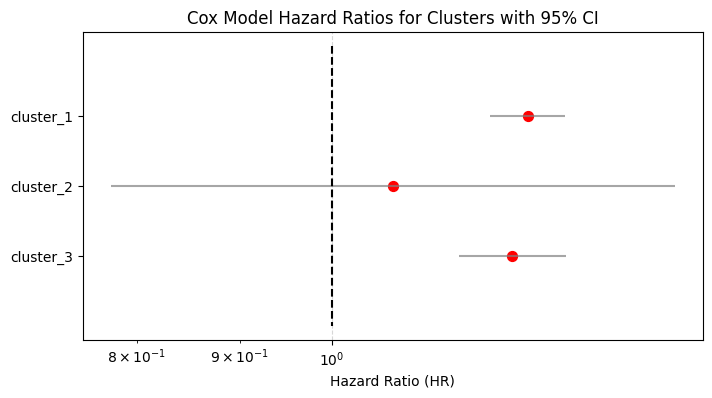

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import CoxPHFitter

# --- Prepare dataframe ---
df_cox = df_model[cluster_features + ['cluster','time_years','event']].copy()

# Convert cluster to categorical (one-hot encoding), baseline = cluster 0
df_cox = pd.get_dummies(df_cox, columns=['cluster'], drop_first=True)

# --- Fit Cox model ---
cph = CoxPHFitter()
cph.fit(df_cox, duration_col='time_years', event_col='event')
cph.print_summary()

# --- Extract summary for plotting ---
summary = cph.summary.reset_index()

# Keep only cluster HRs
cluster_cols = [col for col in summary['covariate'] if col.startswith('cluster_')]
summary_cluster = summary[summary['covariate'].isin(cluster_cols)]

# HRs and 95% CI
hr = summary_cluster['exp(coef)']
hr_lower = summary_cluster['exp(coef) lower 95%']
hr_upper = summary_cluster['exp(coef) upper 95%']
variables = summary_cluster['covariate']

# --- Plot ---
plt.figure(figsize=(8,4))
plt.hlines(variables, hr_lower, hr_upper, color='gray', alpha=0.7)  # CI lines
plt.scatter(hr, variables, color='red', s=50)  # HR points
plt.vlines(1, -1, len(variables), linestyles='dashed', color='black')  # reference line HR=1
plt.xscale('log')
plt.xlabel("Hazard Ratio (HR)")
plt.title("Cox Model Hazard Ratios for Clusters with 95% CI")
plt.gca().invert_yaxis()
plt.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.show()


ML Models

In [ ]:
ml_features = cluster_features + ['cluster']   # from earlier
X = df_model[ml_features]
y = df_model['event']  # mortality (1/0)


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report
)

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import shap


In [ ]:

# Fill missing with medians
X = X.fillna(X.median())

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling (for logistic but optional for tree models)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

print("\n=== RANDOM FOREST ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))



=== RANDOM FOREST ===
Accuracy: 0.6575025842944586
Precision: 0.3960931108852475
Recall: 0.7570717839374556
F1: 0.5200833279083393
ROC-AUC: 0.7611400312597292


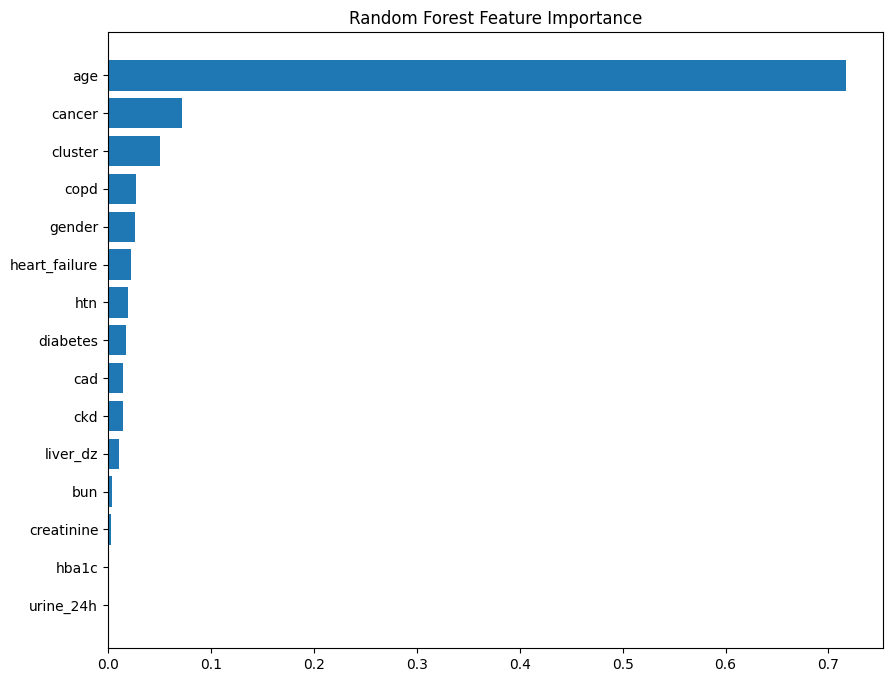

In [ ]:
plt.figure(figsize=(10,8))
importances = rf.feature_importances_
indices = np.argsort(importances)

plt.barh(np.array(ml_features)[indices], importances[indices])
plt.title("Random Forest Feature Importance")
plt.show()


In [ ]:
xgb = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:,1]

print("\n=== XGBOOST ===")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("F1:", f1_score(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))



=== XGBOOST ===
Accuracy: 0.7710257035669071
Precision: 0.582356423919479
Recall: 0.2330253494432599
F1: 0.3328595600676819
ROC-AUC: 0.7661205090202781


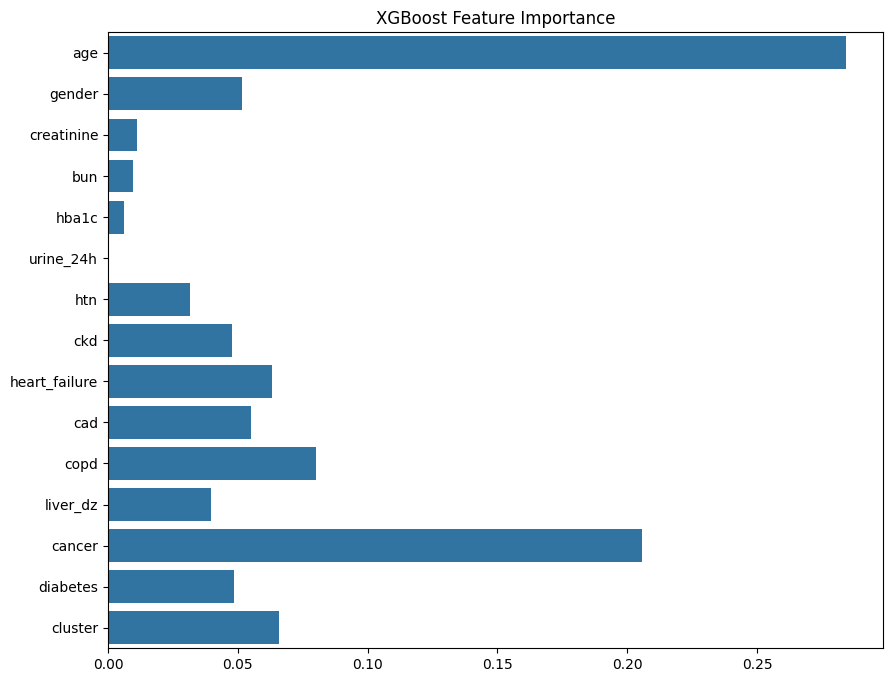

In [ ]:
plt.figure(figsize=(10,8))
sns.barplot(x=xgb.feature_importances_, y=ml_features)
plt.title("XGBoost Feature Importance")
plt.show()


In [ ]:
!pip install scikit-survival
!pip install xgboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 36.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.0/300.0 kB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.1/222.1 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 23.5 MB/s eta 0:00:00
  Attempting uninstall: osqp
    Found existing installation: osqp 1.0.5
    Uninstalling osqp-1.0.5:
      Successfully uninstalled osqp-1.0.5


In [ ]:
from sksurv.util import Surv
from sklearn.model_selection import train_test_split

# Prepare feature matrix
X = df_model[cluster_features + ['cluster']].fillna(0)

# Survival object for scikit-survival
y = Surv.from_dataframe(event="event", time="time_years", data=df_model)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)



ModuleNotFoundError: No module named 'sksurv'

In [ ]:
!pip install scikit-survival
!pip install xgboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.0/300.0 kB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.1/222.1 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 31.8 MB/s eta 0:00:00
  Attempting uninstall: osqp
    Found existing installation: osqp 1.0.5
    Uninstalling osqp-1.0.5:
      Successfully uninstalled osqp-1.0.5


In [ ]:
# ==============================
# Efficient Random Survival Forest
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sksurv.util import Surv
from sksurv.ensemble import RandomSurvivalForest
from sksurv.metrics import concordance_index_censored
from sklearn.model_selection import train_test_split

# --- Ensure 'event' is boolean ---
df_model['event'] = df_model['event'].astype(bool)

# --- Structured survival array ---
y = Surv.from_dataframe(event='event', time='time_years', data=df_model)

# --- Feature matrix ---
X = df_model[cluster_features + ['cluster']].fillna(df_model[cluster_features + ['cluster']].median())

# --- Train-test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --- Optional subsample training to reduce computation ---
max_train = 20000  # max rows for training
if X_train.shape[0] > max_train:
    # Use iloc for proper 0-based indexing
    train_idx = np.random.choice(X_train.shape[0], size=max_train, replace=False)
    X_train = X_train.iloc[train_idx].reset_index(drop=True)
    y_train = y_train[train_idx]

# --- Random Survival Forest (smaller trees for efficiency) ---
rsf = RandomSurvivalForest(
    n_estimators=50,        # fewer trees
    max_depth=6,            # shallower trees
    min_samples_split=20,
    min_samples_leaf=10,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42
)

# --- Fit model ---
rsf.fit(X_train, y_train)

# --- Predict risk scores ---
rsf_pred = rsf.predict(X_test)

# --- Concordance Index ---
cindex = concordance_index_censored(y_test["event"], y_test["time"], rsf_pred)[0]
print("RSF C-index:", round(cindex,4))

# --- Feature importance ---
imp = rsf.feature_importances_
idx = np.argsort(imp)

plt.figure(figsize=(8,6))
sns.barplot(x=imp[idx], y=X.columns[idx])
plt.title("Random Survival Forest — Feature Importance")
plt.xlabel("Importance")
plt.show()


NameError: name 'df_model' is not defined

In [ ]:
from xgboost import XGBRegressor
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sksurv.metrics import concordance_index_censored

# --- Optional subsample for training ---
max_train = 10000  # use 50k rows to reduce computation
if X_train.shape[0] > max_train:
    train_idx = np.random.choice(X_train.shape[0], size=max_train, replace=False)
    X_train_sub = X_train.iloc[train_idx].reset_index(drop=True)
    y_train_time_sub = y_train["time"][train_idx]
else:
    X_train_sub = X_train
    y_train_time_sub = y_train["time"]

# --- XGBoost Cox model (lighter) ---
xgb_cox = XGBRegressor(
    objective="survival:cox",
    eval_metric="cox-nloglik",
    learning_rate=0.05,
    max_depth=4,          # shallower trees
    n_estimators=50,      # fewer trees
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# --- Fit model ---
xgb_cox.fit(X_train_sub, y_train_time_sub)

# --- Predict risk scores ---
xgb_pred = xgb_cox.predict(X_test)

# --- C-index ---
cindex_xgb = concordance_index_censored(
    y_test["event"], y_test["time"], xgb_pred
)[0]
print("XGBoost Cox C-index:", round(cindex_xgb,4))

# --- Feature importance ---
imp = xgb_cox.feature_importances_
idx = np.argsort(imp)

plt.figure(figsize=(8,6))
sns.barplot(x=imp[idx], y=X_train.columns[idx])
plt.title("XGBoost Cox — Feature Importance")
plt.xlabel("Importance")
plt.show()




NameError: name 'X_train' is not defined

In [ ]:
import numpy as np
import pandas as pd

# Total patients
total_patients = df_model['subject_id'].nunique()
print("Total patients:", total_patients)

# Mean age
mean_age = df_model['age'].mean()
print("Mean age:", round(mean_age, 1))

# Female percentage
female_pct = df_model['gender'].mean() * 100  # gender encoded as 0=M, 1=F
print("Female (%):", round(female_pct, 1))

# Median follow-up time (in days)
# Convert time_years back to days
median_followup_days = np.median(df_model['time_years'] * 365.25)
print("Median follow-up (days):", int(median_followup_days))

# Overall mortality (%)
overall_mortality = df_model['event'].mean() * 100
print("Overall mortality (%):", round(overall_mortality, 1))

Total patients: 180386
Mean age: 56.9
Female (%): 52.2
Median follow-up (days): 3
Overall mortality (%): 24.5
